In [1]:
## Import libraries
from pathlib import Path
import pandas as pd
from rasterio.plot import show as display_raster

# from opencropphenotyping.io import find_band
from opencropphenotyping.indices import compute_indexes
from opencropphenotyping.io import read_band, resample_raster, write_png, write_raster
from opencropphenotyping.statistics import compute_statistics
from opencropphenotyping.visualization import plot_statistics

In [2]:
## Find paths to the bands of interest

project_root = Path.cwd().parent
output_dir_processed = project_root / "data" / "processed"
output_dir_images = project_root / "docs" / "images"
output_dir_results = project_root / "results"


# safe_dir = (project_root / "data" / "raw" / "sentinel_2" / "S2A_MSIL2A_20250804T104701_N0511_R051_T31TCJ_20250804T161517.SAFE")

# b04_path = find_band(safe_dir, "B04")
# b08_path = find_band(safe_dir, "B08")

# Use the toy dataset for testing
toy_dir = project_root / "data" / "toy_dataset"

b03_path = toy_dir / "toy_image_b03.tif"
b05_path = toy_dir / "toy_image_b05.tif" #red_edge 20m
b04_path = toy_dir / "toy_image_b04.tif"
b08_path = toy_dir / "toy_image_b08.tif"

print(b03_path.name)
print(b04_path.name)
print(b05_path.name)
print(b08_path.name)

toy_image_b03.tif
toy_image_b04.tif
toy_image_b05.tif
toy_image_b08.tif


In [3]:
## Read the bands
green, green_profile = read_band(b03_path)
red, red_profile = read_band(b04_path)
red_edge_20m, red_edge_20m_profile = read_band(b05_path)
nir, _ = read_band(b08_path)

print(green.shape)
print(green.dtype)

print(red.shape)
print(red.dtype)

print(red_edge_20m.shape)
print(red_edge_20m.dtype)

print(nir.shape)
print(nir.dtype)

print(red_profile)

(512, 512)
uint16
(512, 512)
uint16
(256, 256)
uint16
(512, 512)
uint16
{'driver': 'JP2OpenJPEG', 'dtype': 'uint16', 'nodata': None, 'width': 512, 'height': 512, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'), 'transform': Affine(10.0, 0.0, 340000.0,
       0.0, -10.0, 4840020.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': False}


In [4]:
# Resample the bands to a lower resolution
red_edge_10m, red_edge_10m_profile = resample_raster(
    image = red_edge_20m, 
    profile = red_edge_20m_profile, 
    target_profile = red_profile
    )

print(red_edge_10m.shape)

(512, 512)


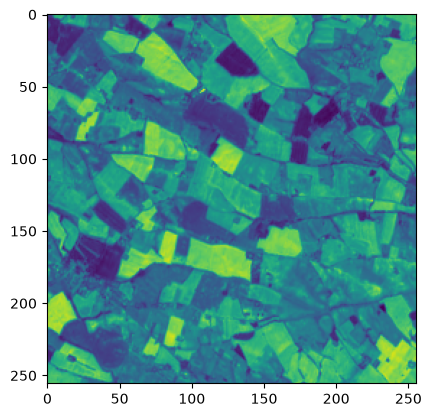

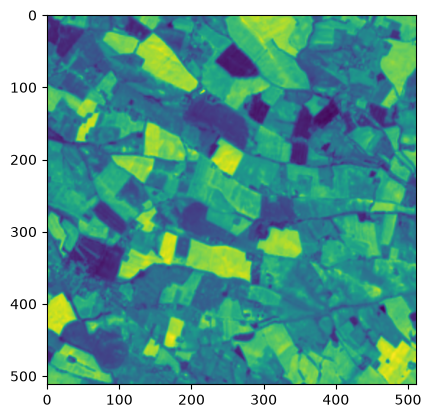

<Axes: >

In [5]:
# Visual check of the resampled red edge band

write_png(red_edge_20m, output_dir_images / "red_edge_20m.png")
display_raster(red_edge_20m)
write_png(red_edge_10m, output_dir_images / "red_edge_10m.png")
display_raster(red_edge_10m)

In [6]:
# Add to documentation

write_png(red, output_dir_images / "red.png")
write_png(red_edge_10m, output_dir_images / "red_edge.png")
write_png(nir, output_dir_images / "nir.png")
write_png(green, output_dir_images / "green.png")

In [7]:
# Compute all indexes

indices = compute_indexes(
    red_band=red,
    nir_band=nir,
    green_band=green,
    red_edge_band=red_edge_10m,
)

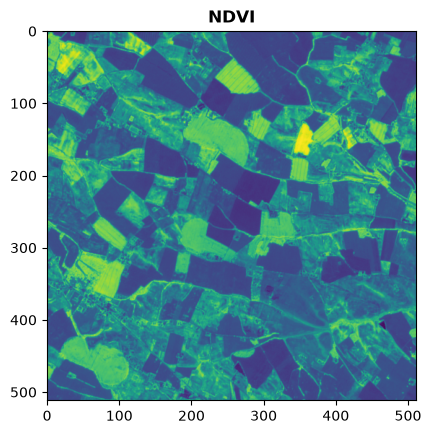

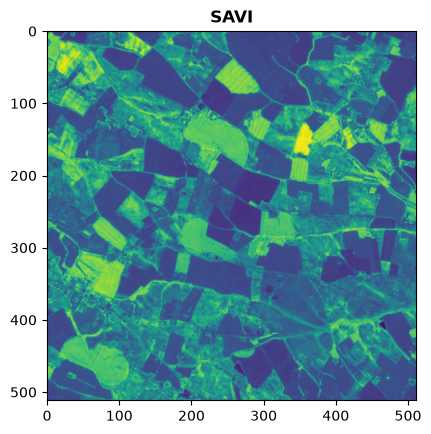

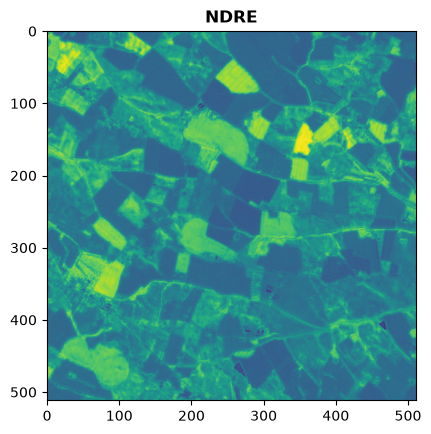

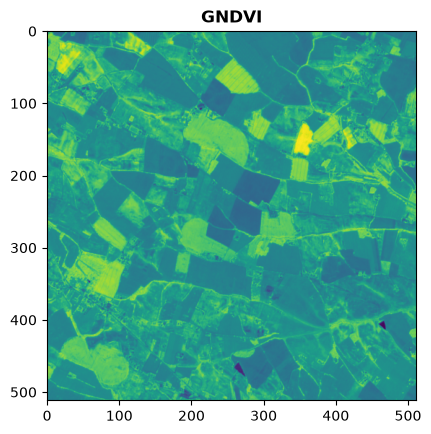

In [8]:
# Visualise and write the results for all indexes
for name, image in indices.items():
    display_raster(image, title=name.upper())
    write_png(image, output_dir_processed / f"{name}.png")
    write_raster(image, red_profile, output_dir_processed / f"{name}.tif")

In [9]:
# Compute statistics from indices

statistics = {}
for name, image in indices.items():
    statistics[name] = compute_statistics(image)

# Display statistics

for index_name, variable_stat in statistics.items():
    print(f"\n{index_name.upper()}")
    for stat_name, stat_value in variable_stat.items():
        print(f"  {stat_name}: {stat_value:.4f}")


NDVI
  min: -0.0534
  max: 0.7221
  mean: 0.2718
  median: 0.2406
  var: 0.0221
  std: 0.1487
  p5: 0.0932
  p25: 0.1384
  p75: 0.3838
  p95: 0.5410

SAVI
  min: -0.0800
  max: 1.0831
  mean: 0.4077
  median: 0.3608
  var: 0.0497
  std: 0.2230
  p5: 0.1398
  p25: 0.2076
  p75: 0.5757
  p95: 0.8115

NDRE
  min: -0.2158
  max: 0.6231
  mean: 0.1848
  median: 0.1543
  var: 0.0141
  std: 0.1189
  p5: 0.0493
  p25: 0.0871
  p75: 0.2554
  p95: 0.4175

GNDVI
  min: -0.1309
  max: 0.6797
  mean: 0.3155
  median: 0.2888
  var: 0.0097
  std: 0.0987
  p5: 0.1890
  p25: 0.2403
  p75: 0.3783
  p95: 0.5024


In [10]:
# Export statistic results

statistics_df = pd.DataFrame.from_dict(statistics, orient="index")
statistics_df.index.name = "index"

print(statistics_df)

statistics_df.to_csv(output_dir_results / "statistics.csv")

            min       max      mean    median       var       std        p5  \
index                                                                         
ndvi  -0.053352  0.722120  0.271820  0.240576  0.022100  0.148661  0.093203   
savi  -0.080014  1.083118  0.407700  0.360836  0.049717  0.222974  0.139796   
ndre  -0.215808  0.623051  0.184778  0.154324  0.014136  0.118893  0.049313   
gndvi -0.130926  0.679711  0.315506  0.288755  0.009738  0.098679  0.189021   

            p25       p75       p95  
index                                
ndvi   0.138398  0.383817  0.541006  
savi   0.207584  0.575681  0.811450  
ndre   0.087107  0.255401  0.417455  
gndvi  0.240327  0.378332  0.502407  


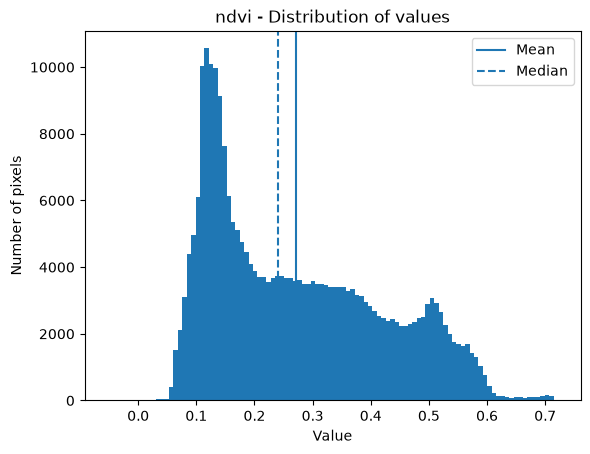

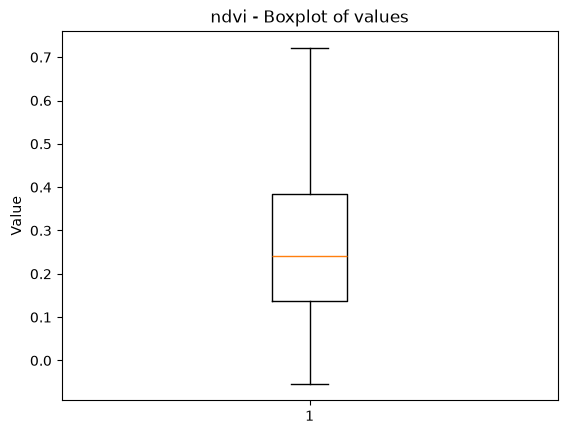

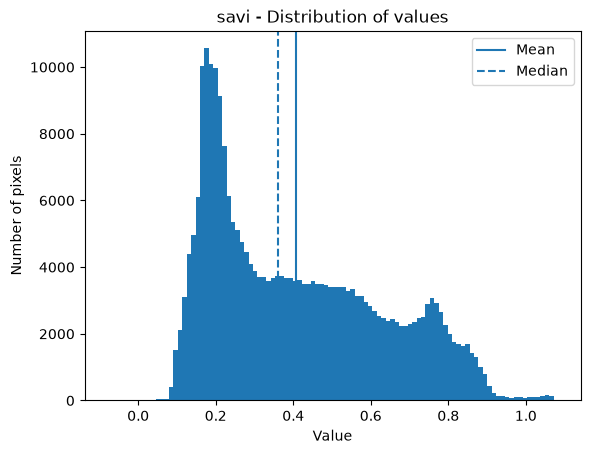

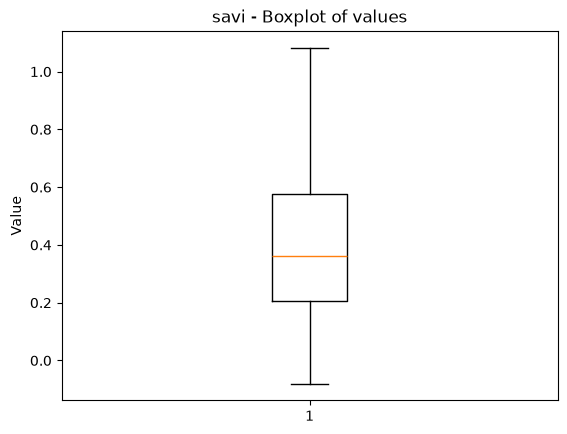

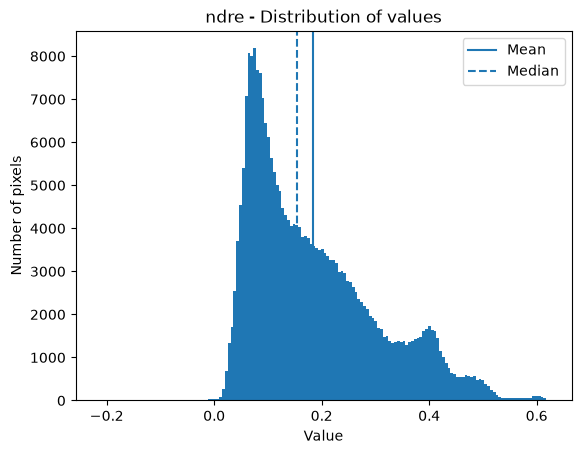

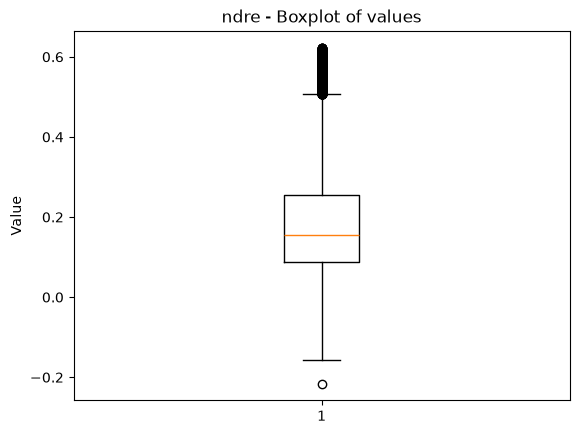

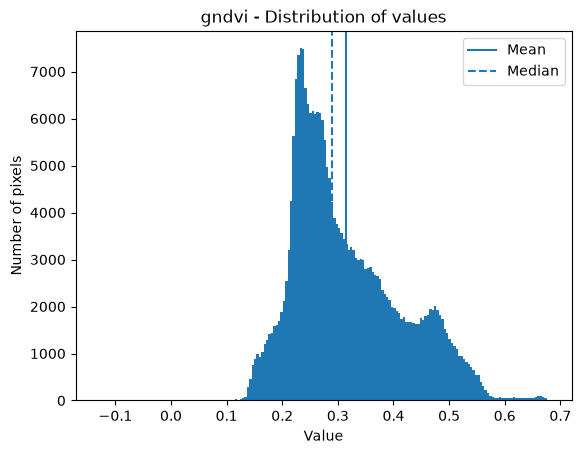

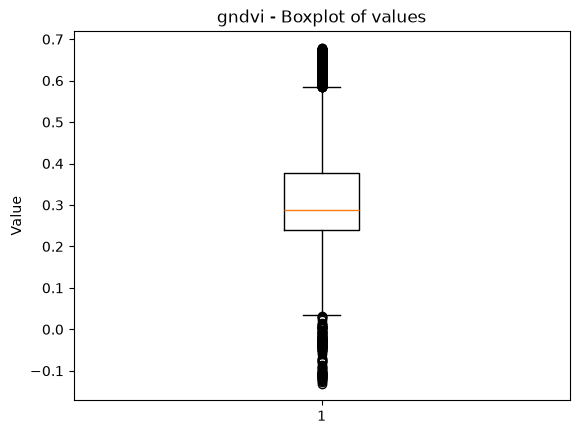

In [ ]:
# Visualize the distribution of pixel values for all indexes

for index_name, image in indices.items():
    figures = plot_statistics(
        image=image,
        statistics=statistics[index_name],
        index_name=index_name
        )

    for i, fig in enumerate(figures):
        fig.savefig(output_dir_images / f"{index_name}_hist_{i}.png")